# 06 — Seniority & Experience

Seniority distribution and experience year requirements across the market. Breaks down how the market is segmented by career level, what experience is expected per job family, and where entry-level roles are geographically concentrated.

In [5]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [6]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, box_plot
from analysis.filters import salary_df

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Seniority Distribution

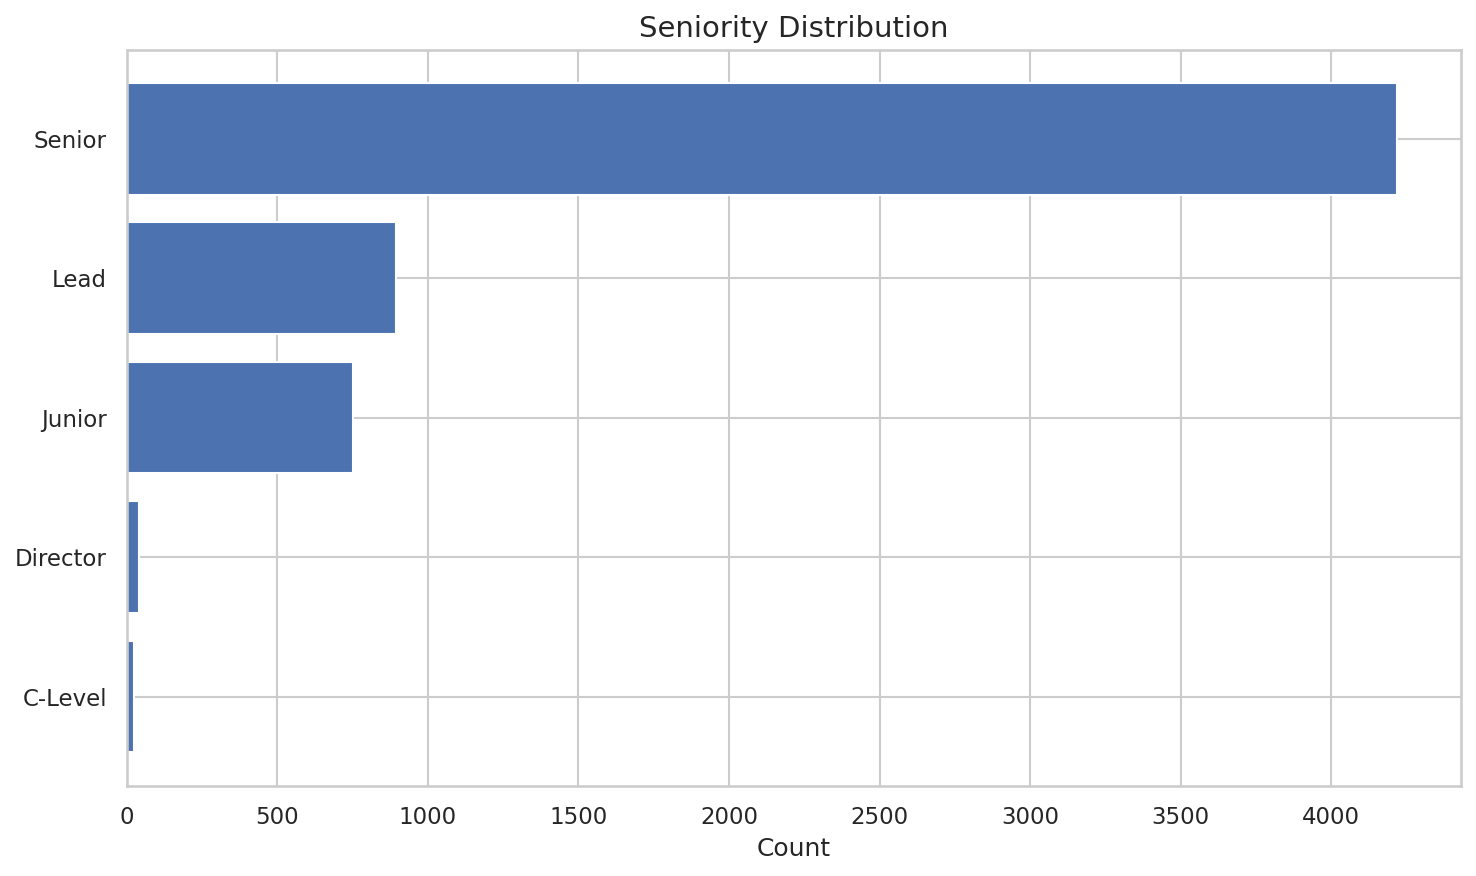

In [7]:
horizontal_bar(
    df["seniority_from_title"],
    "Seniority Distribution",
    save_as="06_seniority.png",
)

## Experience Years Boxplot by Family

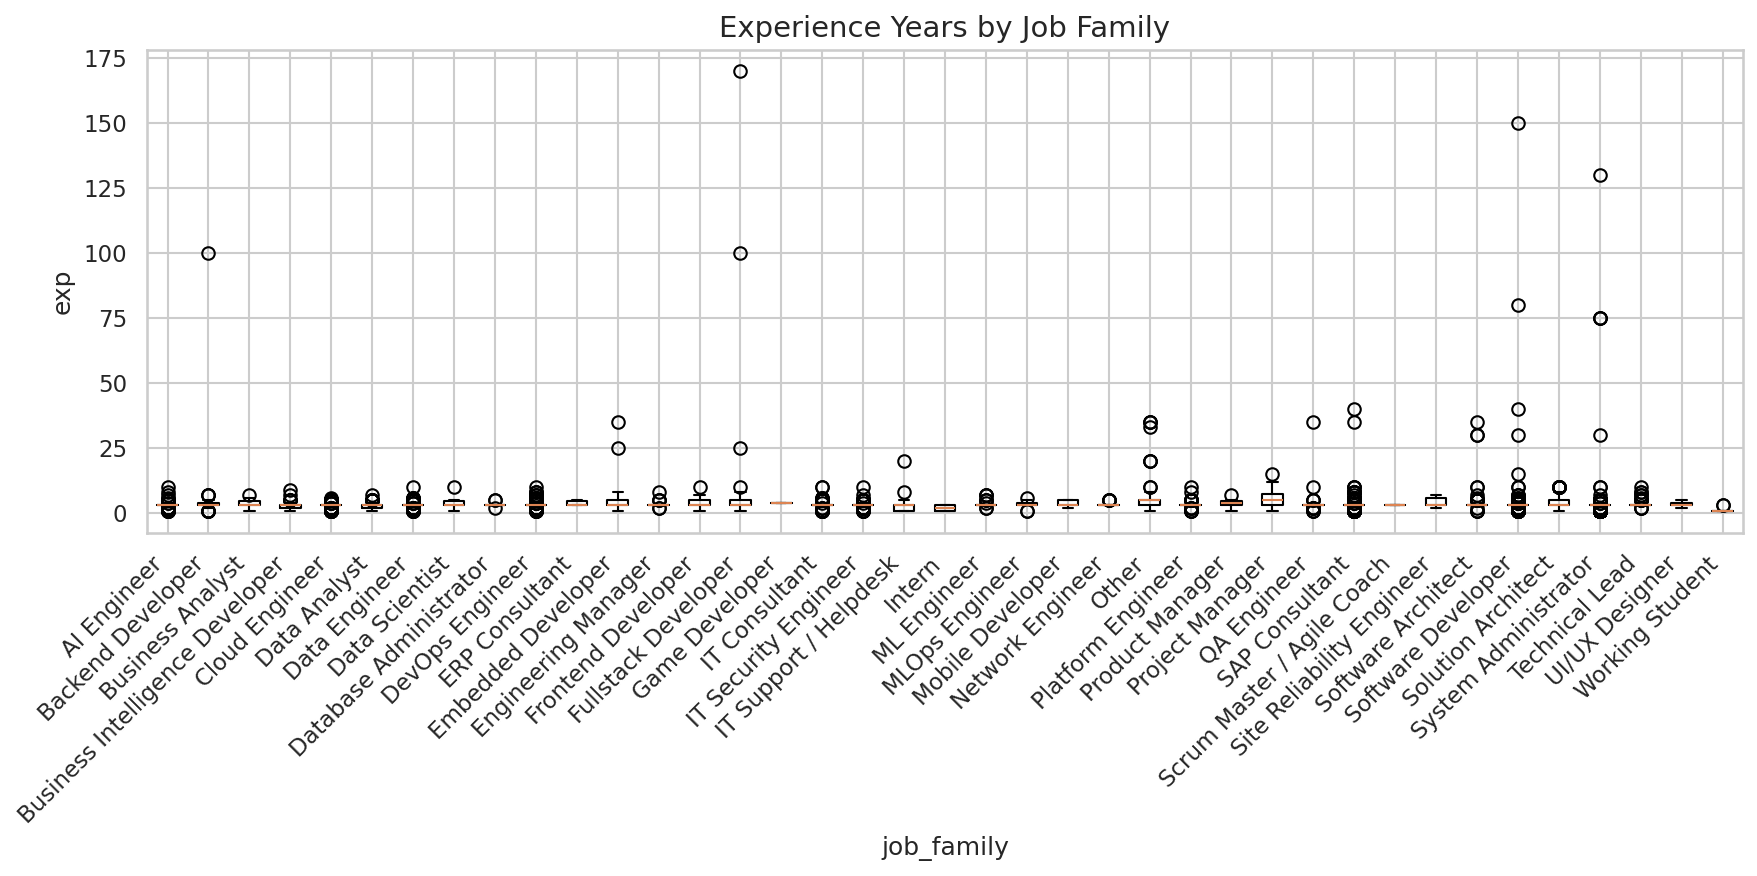

In [8]:
import pandas as pd

exp_df = df[df["experience_years"].notna()].copy()
exp_df["exp"] = pd.to_numeric(exp_df["experience_years"]).astype(int)
box_plot(
    exp_df,
    "job_family",
    "exp",
    "Experience Years by Job Family",
    save_as="06_exp_family.png",
)

## Entry-level Density by City

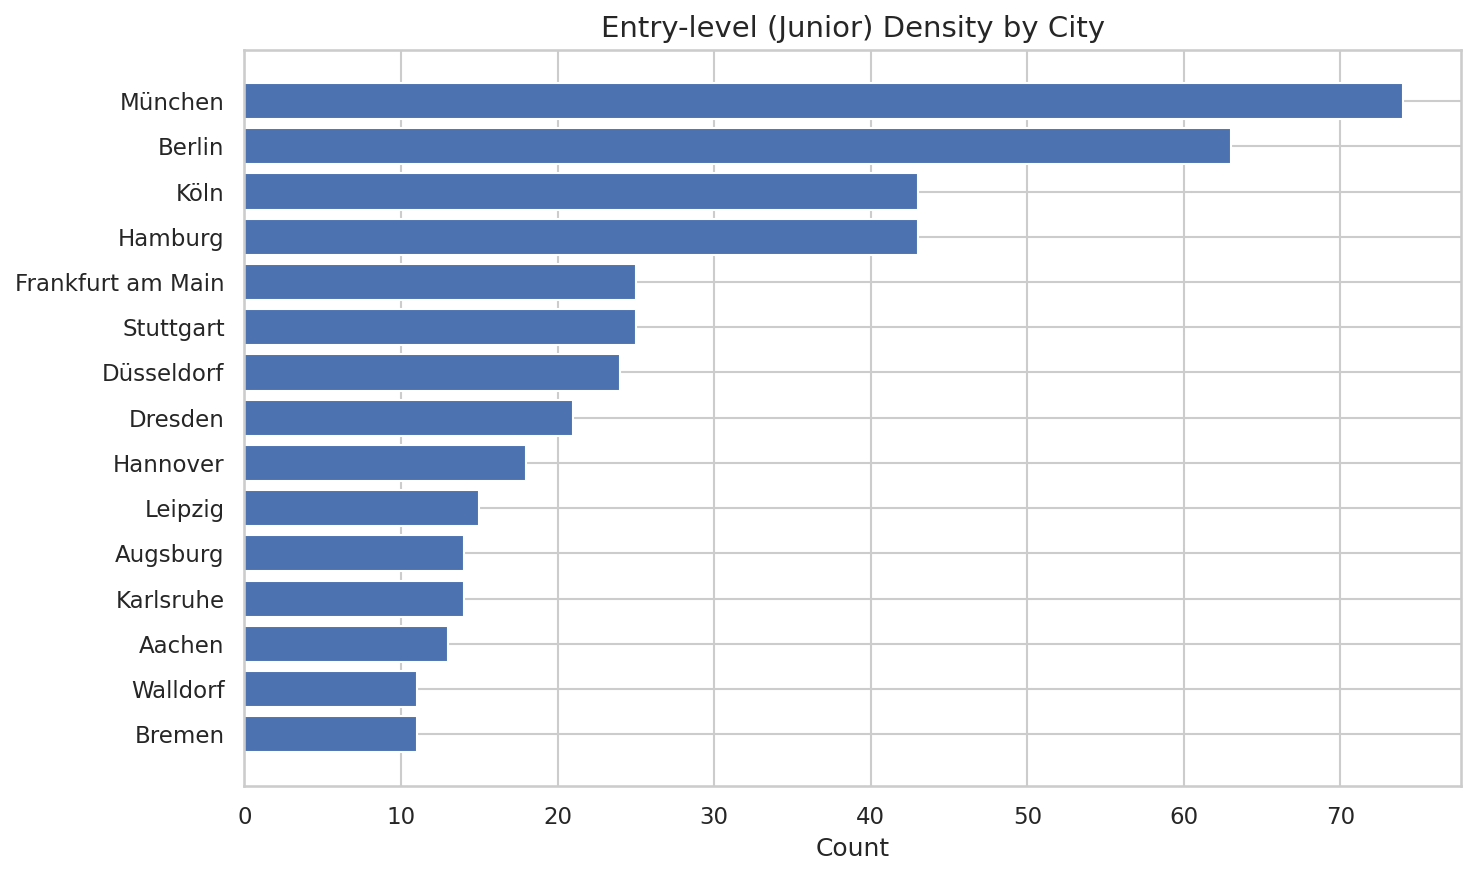

In [9]:
junior_df = df[(df["seniority_from_title"].str.lower() == "junior") & (df["city"].notna())]
horizontal_bar(
    junior_df["city"],
    "Entry-level (Junior) Density by City",
    top_n=15,
    save_as="06_junior_cities.png",
)

## Seniority vs Salary

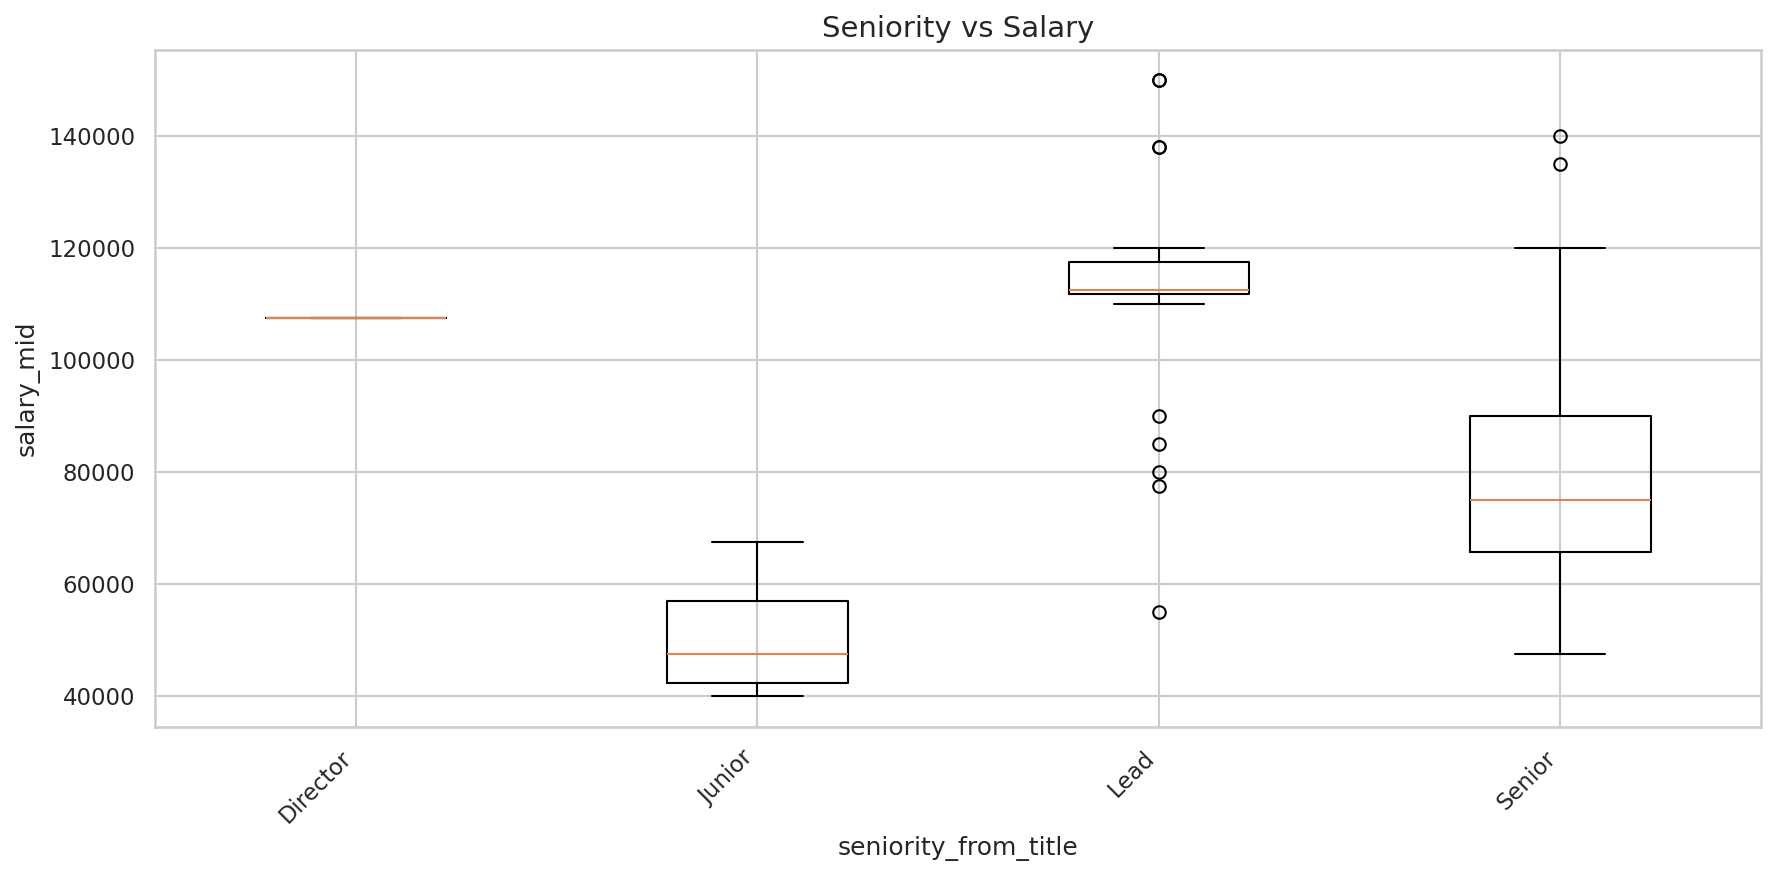

In [10]:
sdf = salary_df(df)
box_plot(
    sdf,
    "seniority_from_title",
    "salary_mid",
    "Seniority vs Salary",
    save_as="06_seniority_salary.png",
)